# Questão 4 - Dados Públicos

### Cenário

O Sr. Almir identificou que alguns produtos podem ter sido vendidos abaixo do custo, possivelmente por erro operacional.

O problema é que:

- O sistema de vendas (`vendas_2023_2024.csv`) registra valores em **real BRL**
- O catálogo de fornecedores (`custos_importacao.json`) registra custos unitários em **dólar USD**
- O câmbio varia diariamente

Até hoje, ninguém cruzou o custo em dólar do dia da venda com o valor de venda em reais.

Sua missão é abrir essa "caixa preta" financeira e identificar onde houve prejuízo real.

### Premissas obrigatórias:

- O custo em USD é unitário
- O custo em BRL deve ser calculado usando o cambio da data da venda
- A taxa de câmbio deve ser considerada a média da cotação de venda do dia (Banco Central)
- A receita total do produto considera todas as vendas (inclusive as sem prejuizo)
- Ignore impostos e frete

### Tarefas:

> Parte 1 - Calculo e Modelagem
> 
- Calcule o custo total em BRL por transação
- Identifique transações com prejuízo
- Agregue os dados por `id_produto`, gerando:
    1. Receita total (BRL)
    2. Prejuízo total (BRL)
    3. Percentual de perda (`prejuizo_total / receita_total`)

> Parte 2- Análise Visual
> 

Gere um gráfico que represente o prejuízo total por produto, considerando apenas produtos que
tiveram prejuízo. *(inserir o gráfico no relatório/dashboard final)*

> Parte 3 - Análise Objetiva
> 

**Responda objetivamente:**

- Qual produto concentra o maior prejuízo absoluto?
- O produto com maior prejuízo absoluto também e o que possui a maior porcentagem de perda? (Sim ou Não)

In [19]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

> Parte 0 - Extraindo dados de câmbio de venda (dólar)

In [20]:
# Obter dados de câmbio por meio do BCB
data_inicial = '12-30-2022'
data_final = '12-31-2024'

# A URL já precisa ser construída com as datas embutidas no formato OData
url = f"https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/CotacaoDolarPeriodo(dataInicial=@dataInicial,dataFinalCotacao=@dataFinalCotacao)?@dataInicial='{data_inicial}'&@dataFinalCotacao='{data_final}'&$format=json"

response = requests.get(url)

if response.status_code == 200:
    data = response.json()
    df_cambio = pd.DataFrame(data['value']) 
    display(df_cambio)
else:
    print(f"Erro: {response.status_code}")

,cotacaoCompra,cotacaoVenda,dataHoraCotacao
0,5.22,5.22,2022-12-30 10:05:02.267
1,5.34,5.34,2023-01-02 13:05:57.593
2,5.38,5.38,2023-01-03 13:11:19.08
3,5.45,5.45,2023-01-04 13:09:19.572
4,5.40,5.40,2023-01-05 13:03:32.262
...,...,...,...
498,6.15,6.15,2024-12-24 11:10:05.681
499,6.17,6.17,2024-12-26 13:09:30.003
500,6.20,6.20,2024-12-27 13:03:30.393
501,6.19,6.19,2024-12-30 13:06:26.618


In [21]:
# Converter a data e extrair apenas o dia (normalizado para 00:00:00)
df_cambio['dataHoraCotacao'] = pd.to_datetime(df_cambio['dataHoraCotacao'])
df_cambio['data'] = df_cambio['dataHoraCotacao'].dt.normalize() 

# Renomear para o padrão e selecionar a coluna de venda
df_cambio = df_cambio.rename(columns={'cotacaoVenda': 'cotacao_dolar'})

# Fazer a média diária 
df_cambio = df_cambio.groupby('data')['cotacao_dolar'].mean().reset_index()

# Criar o calendário completo (Sábados, Domingos e Feriados)
df_cambio = df_cambio.set_index('data')
data_min = df_cambio.index.min()
data_max = df_cambio.index.max()
calendario_completo = pd.date_range(start=data_min, end=data_max, freq="D")

# Reindexar (o que cria os dias vazios) e aplicar o Forward Fill (ffill)
df_cambio = df_cambio.reindex(calendario_completo)
df_cambio['cotacao_dolar'] = df_cambio['cotacao_dolar'].ffill().bfill()

# Resetar o índice, renomear a coluna de datas e deixar pronto para uso
df_cambio = df_cambio.reset_index().rename(columns={"index": "data_cambio"})

print(f"Câmbio tratado: {len(df_cambio)} dias | Valores nulos: {df_cambio['cotacao_dolar'].isna().sum()}")
display(df_cambio.head(10))

Câmbio tratado: 733 dias | Valores nulos: 0


,data_cambio,cotacao_dolar
0,2022-12-30,5.22
1,2022-12-31,5.22
2,2023-01-01,5.22
3,2023-01-02,5.34
4,2023-01-03,5.38
5,2023-01-04,5.45
6,2023-01-05,5.40
7,2023-01-06,5.29
8,2023-01-07,5.29
9,2023-01-08,5.29


In [22]:
df_cambio.info()

<class 'pandas.DataFrame'>
RangeIndex: 733 entries, 0 to 732
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   data_cambio    733 non-null    datetime64[us]
 1   cotacao_dolar  733 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 11.6 KB


In [23]:
# Exportar para CSV
df_cambio.to_csv('../datasets/processed/historico_cambio_bcb.csv', index=False)
print("Ficheiro 'historico_cambio_bcb' guardado com sucesso!")

Ficheiro 'historico_cambio_bcb' guardado com sucesso!


In [24]:
# Carregar Vendas e Custos
vendas = pd.read_csv('../datasets/processed/vendas_normalizadas.csv')
custos = pd.read_csv('../datasets/processed/custos_importacao.csv')
df_cambio = pd.read_csv('../datasets/processed/historico_cambio_bcb.csv')

In [25]:
print(f"Nulos vendas: {vendas['sale_date'].isnull().sum()}")
print(f"Nulos custos: {custos['start_date'].isnull().sum()}")

Nulos vendas: 0
Nulos custos: 0


In [26]:
# Preparação dos tipos de dados
# Garantir que o df_cambio use o 'data_cambio' e seja datetime
df_cambio['data_cambio'] = pd.to_datetime(df_cambio['data_cambio'])

# Garantir que vendas e custos também seja datetime
vendas['sale_date'] = pd.to_datetime(vendas['sale_date'])
custos['start_date'] = pd.to_datetime(custos['start_date'])

In [27]:
# Ordenando pela data
vendas = vendas.sort_values('sale_date')
custos = custos.sort_values('start_date')
df_cambio = df_cambio.sort_values('data_cambio')

In [28]:
# Merge de Câmbio + Vendas
# Unindo vendas com o câmbio do dia
vendas_cambio = pd.merge(
    vendas,
    df_cambio[['data_cambio', 'cotacao_dolar']],
    left_on='sale_date',
    right_on='data_cambio',
    how='left'
)

vendas_cambio.head()

,id,id_client,id_product,qtd,total,sale_date,data_cambio,cotacao_dolar
0,1230,17,91,4,"512,566.80",2023-01-01,2023-01-01,5.22
1,2300,30,95,9,"596,858.40",2023-01-01,2023-01-01,5.22
2,3131,28,130,13,"53,873.00",2023-01-01,2023-01-01,5.22
3,4212,9,96,6,"402,538.75",2023-01-01,2023-01-01,5.22
4,4294,7,44,5,"51,332.30",2023-01-01,2023-01-01,5.22


In [29]:
# Padronizando a coluna 'product_id' de custos_importacao
custos = custos.rename(columns={'product_id': 'id_product'})
custos.head(1)

,id_product,product_name,category,start_date,usd_price
402,47,Rádio Simrad Tidal Aqua,eletrônicos,2016-01-04,"1,516.33"


In [30]:
# Merge de Custos - Vendas/Câmbio + Custos
# Ordenação obrigatória para merge_asof
vendas_cambio = vendas_cambio.sort_values('sale_date')
custos = custos.sort_values('start_date')

# Cruzamento final
df_final = pd.merge_asof(
    vendas_cambio,
    custos[['id_product', 'start_date', 'usd_price', 'product_name']],
    left_on='sale_date',
    right_on='start_date',
    left_by='id_product',
    right_by='id_product',
    direction='backward'
)

print(f"Vendas cruzadas com cÂmbio e custos: {df_final.shape[0]} linhas")
print(df_final.head())

Vendas cruzadas com cÂmbio e custos: 9895 linhas
     id  id_client  id_product  qtd        total  sale_date data_cambio  \
0  1230         17          91    4   512,566.80 2023-01-01  2023-01-01   
1  8211         14          67    3   257,367.00 2023-01-01  2023-01-01   
2   666         14          15    5   132,524.05 2023-01-01  2023-01-01   
3  5256         19          78   12 1,461,139.00 2023-01-01  2023-01-01   
4  3549         10          53   13   662,886.25 2023-01-01  2023-01-01   

   cotacao_dolar start_date  usd_price  \
0           5.22 2022-03-16  26,303.31   
1           5.22 2022-06-17  16,720.73   
2           5.22 2022-12-06   5,325.40   
3           5.22 2022-10-14  23,053.04   
4           5.22 2022-07-19   9,958.63   

                                    product_name  
0    Motor Elétrico Tohatsu Zenith Oceanic 113HP  
1                Motor de Popa Yamaha Mako 108HP  
2                      Radar Garmin Tidal Thrust  
3           Motor Elétrico Honda Mako Axis 

In [31]:
# Salvando a base normalizada para uso nas próximas análises
df_final.to_csv('../datasets/processed/vendas_cambio_custos.csv', index=False)
print(" Arquivo salvo - vendas_cambio_custos.csv")

 Arquivo salvo - vendas_cambio_custos.csv


> Parte 1 - Cálculo e Modelagem

In [32]:
# Define como vai ser exibido os números float de forma global
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Custo unitário em BRL
# O usd_price do catálogo é UNITÁRIO, então custo_brl também é unitário
df_final["custo_brl"] = df_final["usd_price"] * df_final["cotacao_dolar"]

# Custo TOTAL da transação (unitário × quantidade) 
df_final["custo_total_brl"] = df_final["custo_brl"] * df_final["qtd"]

# Valor de prejuízo por transação 
df_final["prejuizo"] = df_final["custo_total_brl"] > df_final["total"]

df_final["valor_prejuizo"] = np.where(
    df_final["prejuizo"],
    df_final["custo_total_brl"] - df_final["total"],
    0.0
)

In [33]:
# Conferência
transacoes_com_prejuizo = df_final[df_final["prejuizo"]]
print('-'*90)
print(f"Transações com prejuízo: {len(transacoes_com_prejuizo)}")
print('-'*90)
print(transacoes_com_prejuizo[
    ["id", "sale_date", "product_name", "total", "custo_total_brl", "valor_prejuizo"]
].head())
print('-'*90)

------------------------------------------------------------------------------------------
Transações com prejuízo: 6179
------------------------------------------------------------------------------------------
     id  sale_date                                   product_name      total  \
0  1230 2023-01-01    Motor Elétrico Tohatsu Zenith Oceanic 113HP 512,566.80   
1  8211 2023-01-01                Motor de Popa Yamaha Mako 108HP 257,367.00   
2   666 2023-01-01                      Radar Garmin Tidal Thrust 132,524.05   
4  3549 2023-01-01  Motor Elétrico Torqeedo Zen Titan Hydra 129HP 662,886.25   
5  7765 2023-01-01                   Transponder Furuno Force Ion  74,960.70   

   custo_total_brl  valor_prejuizo  
0       548,971.12       36,404.32  
1       261,731.26        4,364.26  
2       138,931.70        6,407.65  
4       675,494.87       12,608.62  
5        79,629.09        4,668.39  
-------------------------------------------------------------------------------------

In [34]:
# Agregar por id_product 
resultado = df_final.groupby(["id_product", "product_name"]).agg(
    receita_total   = ("total",          "sum"),
    custo_total_brl = ("custo_total_brl","sum"),
    prejuizo_total  = ("valor_prejuizo", "sum"),
    n_vendas        = ("id",             "count"),
    n_transacoes_prejuizo = ("prejuizo", "sum")
).reset_index()

# Percentual de perda = prejuízo total / receita total
resultado["pct_perda"] = (
    resultado["prejuizo_total"] / resultado["receita_total"] * 100
).round(2)

resultado = resultado.sort_values("prejuizo_total", ascending=False)

print('-'*90)
print("Top 10 produtos com maior prejuízo:")
print('-'*90)
print(resultado[resultado["prejuizo_total"] > 0][
    ["product_name", "receita_total", "prejuizo_total", "pct_perda"]
].head(10).to_string())
print('-'*90)

------------------------------------------------------------------------------------------
Top 10 produtos com maior prejuízo:
------------------------------------------------------------------------------------------
                                    product_name  receita_total  prejuizo_total  pct_perda
71          Motor de Popa Volvo Hydro Dash 256HP  63,057,815.65   39,821,041.68      63.15
82          Motor Diesel Yanmar Dash Nitro 184HP  44,377,440.00   18,614,294.87      41.95
73              Motor de Popa Honda Torque 228HP  59,764,356.15    6,716,610.31      11.24
70           Motor Elétrico Torqeedo Pulse 300HP  81,567,066.65    6,070,816.06       7.44
54         Motor Diesel Volvo Flow Oceanic 259HP  61,224,375.00    5,371,141.28       8.77
90   Motor Elétrico Tohatsu Zenith Oceanic 113HP  66,829,268.70    4,883,920.30       7.31
62    Motor Elétrico Torqeedo Ion Orca Vox 186HP  68,817,185.90    4,848,430.38       7.05
77          Motor Elétrico Honda Mako Axis 131HP  58,0

> Parte 2 - Análise Visual

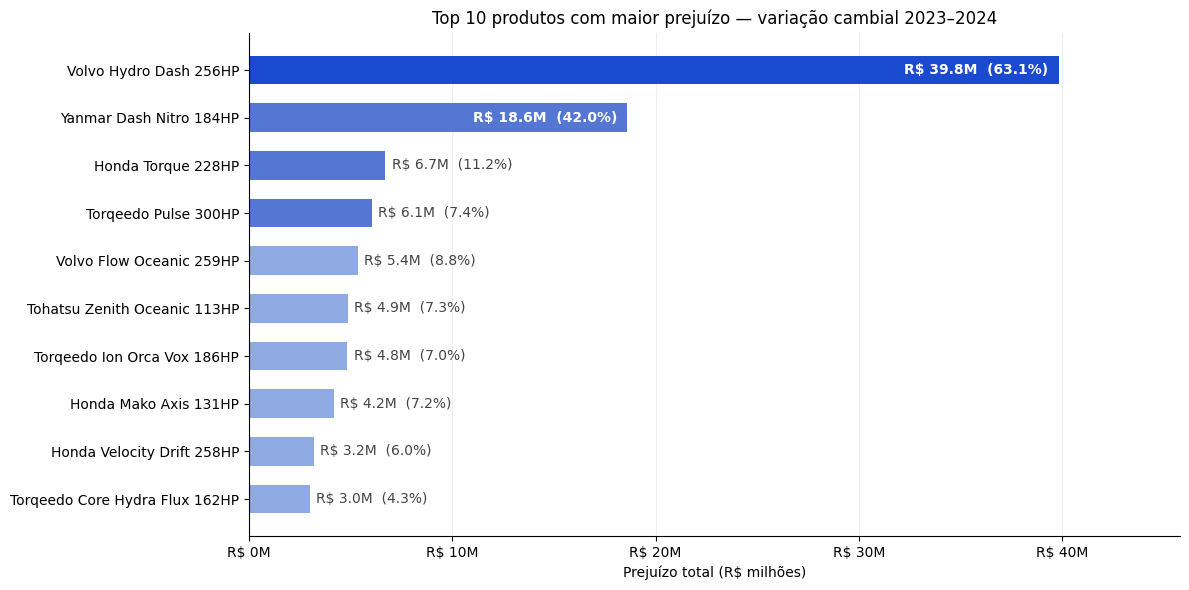

In [35]:
top10 = (
    resultado[resultado["prejuizo_total"] > 0]
    .nlargest(10, "prejuizo_total")
    .sort_values("prejuizo_total", ascending=True)
)

nomes   = top10["product_name"].str.replace(r"Motor (de Popa |Diesel |Elétrico )", "", regex=True)
valores = top10["prejuizo_total"] / 1e6
pcts    = top10["pct_perda"]
cores   = ["#1A4ACF" if v == max(valores) else "#5577D4" if v >= 6 else "#8FA9E2"
           for v in valores]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(nomes, valores, color=cores, height=0.6)

limiar = valores.max() * 0.35  # barras acima disso recebem rótulo interno

for bar, v, p in zip(bars, valores, pcts):
    label = f"R$ {v:.1f}M  ({p:.1f}%)"
    if v >= limiar:
        ax.text(v - 0.5, bar.get_y() + bar.get_height() / 2,
                label, va="center", ha="right",
                fontsize=10, color="white", fontweight="bold")
    else:
        ax.text(v + 0.3, bar.get_y() + bar.get_height() / 2,
                label, va="center", ha="left",
                fontsize=10, color="#444")

ax.set_xlim(0, valores.max() * 1.15)
ax.set_xlabel("Prejuízo total (R$ milhões)")
ax.set_title("Top 10 produtos com maior prejuízo — variação cambial 2023–2024")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R$ {x:.0f}M'))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#eee", linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("grafico_prejuizo.png", dpi=150, bbox_inches="tight")
plt.show()

> Parte 3 - Análise Objetiva

In [36]:
# Produto com maior prejuízo ABSOLUTO
maior_abs = resultado.loc[resultado["prejuizo_total"].idxmax()]

# Produto com maior PERCENTUAL de perda
maior_pct = resultado.loc[resultado["pct_perda"].idxmax()]

print("-" * 70)
print("Produto com MAIOR PREJUÍZO ABSOLUTO:")
print(f"  → {maior_abs['product_name']}")
print(f"  → Prejuízo: R$ {maior_abs['prejuizo_total']:,.2f}")
print(f"  → % Perda:  {maior_abs['pct_perda']:.2f}%\n")

print("-" * 70)
print("Produto com MAIOR % DE PERDA:")
print(f"  → {maior_pct['product_name']}")
print(f"  → % Perda:  {maior_pct['pct_perda']:.2f}%\n")

# Resposta objetiva
mesmo_produto = maior_abs["id_product"] == maior_pct["id_product"]
print("-" * 70)
print("O produto com maior prejuízo absoluto também tem a maior % de perda?")
print(f"  → {'SIM' if mesmo_produto else 'NÃO'}")

----------------------------------------------------------------------
Produto com MAIOR PREJUÍZO ABSOLUTO:
  → Motor de Popa Volvo Hydro Dash 256HP
  → Prejuízo: R$ 39,821,041.68
  → % Perda:  63.15%

----------------------------------------------------------------------
Produto com MAIOR % DE PERDA:
  → Motor de Popa Volvo Hydro Dash 256HP
  → % Perda:  63.15%

----------------------------------------------------------------------
O produto com maior prejuízo absoluto também tem a maior % de perda?
  → SIM
